# Quantum Amplitude Amplification (QAA)

Grover's algorithm is fantastic for unstructured search, but what if our database isn't uniformly distributed? What if we have a heuristic or an algorithm $\mathcal{A}$ that gives us a good "first guess" distribution?

**Quantum Amplitude Amplification (QAA)** is the generalization of Grover's algorithm. Instead of using Hadamard gates to create a uniform superposition, we use an arbitrary state preparation circuit $\mathcal{A}$. Consequently, our Diffuser must also change: instead of reflecting around the uniform state, it reflects around the state created by $\mathcal{A}$.

## 1. Import Libraries
Let's import Qiskit and define our base parameters. We'll use a 2-qubit system for simplicity.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

num_qubits = 2
target_state = '11'  # The state we want to amplify

## 2. State Preparation (Operator $\mathcal{A}$)
Instead of Hadamard gates, we'll use $R_y$ rotation gates with a small angle. This simulates a scenario where our initial algorithm $\mathcal{A}$ creates a biased distribution. The state $|11\rangle$ will have a naturally very low probability of being measured.

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hr/hhkl0v7n3qjc9jcwn86t3r840000gn/T/ipykernel_20117/4291665452.py:12: SyntaxWarning: invalid escape sequence '\d'
  qc = QuantumCircuit(num_qubits, name=' A^\dagger ')


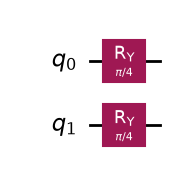

In [2]:
# We choose an angle that heavily biases the state towards |00>
# and makes |11> very unlikely.
theta = np.pi / 4  

def create_A_operator():
    qc = QuantumCircuit(num_qubits, name=' A ')
    for q in range(num_qubits):
        qc.ry(theta, q)
    return qc

def create_A_inverse_operator():
    qc = QuantumCircuit(num_qubits, name=' A^\dagger ')
    for q in range(num_qubits):
        # Inverse operation is just negative rotation
        qc.ry(-theta, q)
    return qc

A_gate = create_A_operator()
display(A_gate.draw('mpl'))

Let's verify how bad our initial distribution is before amplification:

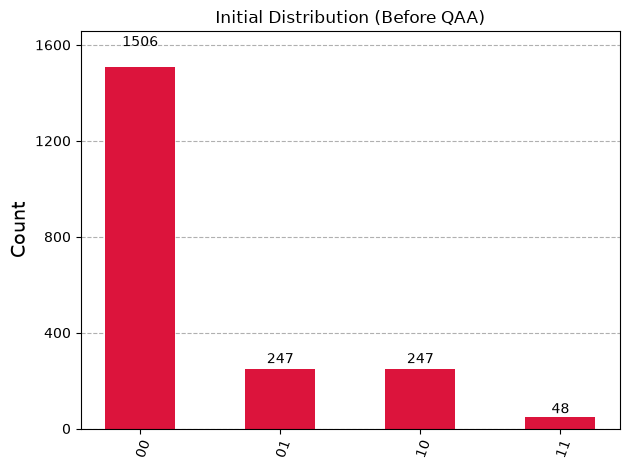

In [3]:
test_qc = QuantumCircuit(num_qubits, num_qubits)
test_qc.append(A_gate, range(num_qubits))
test_qc.measure(range(num_qubits), range(num_qubits))

simulator = AerSimulator()
counts_before = simulator.run(transpile(test_qc, simulator), shots=2048).result().get_counts()
display(plot_histogram(counts_before, title="Initial Distribution (Before QAA)", color='crimson'))

## 3. The Oracle
The oracle remains exactly the same as in Grover's algorithm. It recognizes the target state (e.g., $|11\rangle$) and applies a negative phase.

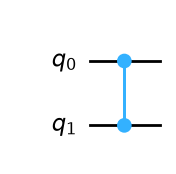

In [4]:
def create_oracle():
    qc = QuantumCircuit(num_qubits, name=' Oracle ')
    # For state |11>, a simple Controlled-Z is sufficient
    qc.cz(0, 1)
    return qc

oracle_gate = create_oracle()
display(oracle_gate.draw('mpl'))

## 4. Generalized QAA Diffuser
Here is the core difference. A generalized diffuser performs reflection around the starting state $|\psi\rangle = \mathcal{A}|0\rangle$. 
The mathematical structure is: $\mathcal{A} Z_0 \mathcal{A}^\dagger$

1. **Uncompute:** Apply $\mathcal{A}^\dagger$ to return to the computational basis.
2. **Reflect:** Apply phase flip to the $|00\rangle$ state ($Z_0$).
3. **Compute:** Apply $\mathcal{A}$ to return to our biased superposition.

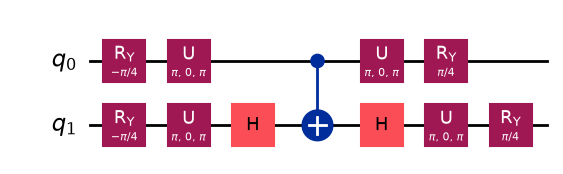

In [5]:
def create_qaa_diffuser():
    qc = QuantumCircuit(num_qubits, name=' QAA Diffuser ')
    
    # 1. Apply inverse of A
    qc.append(create_A_inverse_operator(), range(num_qubits))
    
    # 2. Reflect around |00> (Apply phase -1 to state |00>)
    # Flip 0s to 1s
    qc.x(range(num_qubits))
    # Apply Controlled-Z
    qc.cz(0, 1)
    # Flip back
    qc.x(range(num_qubits))
    
    # 3. Apply A
    qc.append(create_A_operator(), range(num_qubits))
    
    return qc

diffuser_gate = create_qaa_diffuser()
display(diffuser_gate.decompose().draw('mpl'))

## 5. Circuit Assembly and Simulation
Even though the probability of measuring $|11\rangle$ was initially less than 2%, applying QAA will amplify this amplitude significantly.

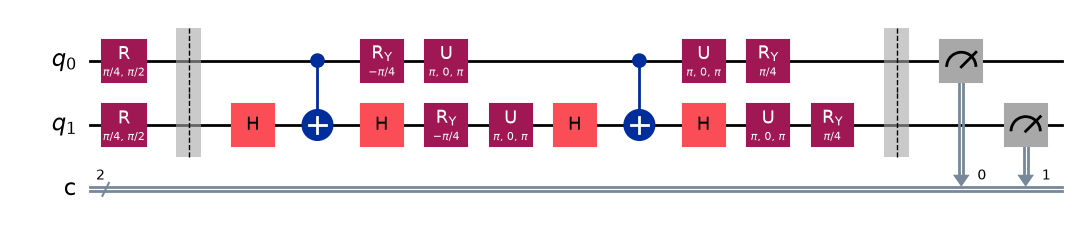

In [6]:
qaa_circuit = QuantumCircuit(num_qubits, num_qubits)

# Step 0: Initial state preparation using operator A
qaa_circuit.append(A_gate, range(num_qubits))
qaa_circuit.barrier()

# QAA Iteration (Applying once is enough to see the effect here)
qaa_circuit.append(oracle_gate, range(num_qubits))
qaa_circuit.append(diffuser_gate, range(num_qubits))
qaa_circuit.barrier()

qaa_circuit.measure(range(num_qubits), range(num_qubits))

display(qaa_circuit.decompose(reps=2).draw('mpl'))

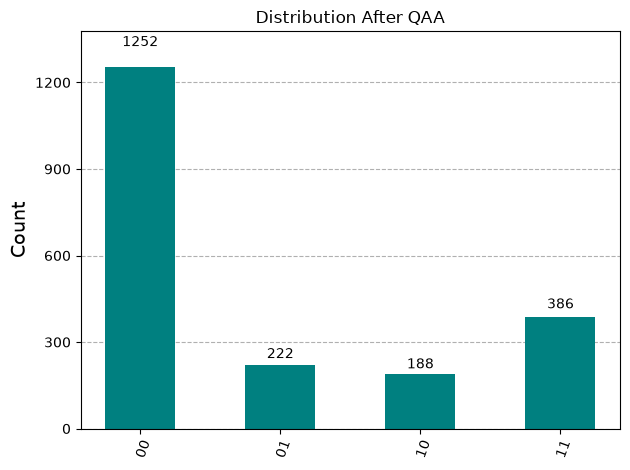

In [7]:
transpiled_qaa = transpile(qaa_circuit, simulator)
counts_after = simulator.run(transpiled_qaa, shots=2048).result().get_counts()

display(plot_histogram(counts_after, title="Distribution After QAA", color='teal'))